Nombre y apellidos: Alfonso Íñiguez Cortés\
Correo: aic35@galu.ua.es\
Grupo: 3

In [2]:
# Random walk

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def random_walk_numpy(graph, source, target, max_steps=1000, seed=42):
    """
    Implementation of Random Walk using NumPy and standard Python lists
    
    Parameters:
    - graph: NetworkX graph (undirected, unweighted)
    - source: Source node
    - target: Target node
    - max_steps: Maximum number of steps before giving up
    - seed: Random seed for reproducibility
    
    Returns:
    - steps: Number of steps needed to find the solution
    - path: List of nodes in the path from source to target
    - success: Boolean indicating whether the target was found
    """
    np.random.seed(seed)

    nodes = list(graph.nodes())
    source_index = nodes.index(source)
    target_index = nodes.index(target)

    adjacency_matrix = nx.to_numpy_array(graph, nodelist=nodes)

    steps = 0

    success = False

    path = [source_index]   

    while steps < max_steps:
        steps  += 1
        valor_actual = path[-1]
        if valor_actual == target_index:
            success = True
            break

        neighbors = np.where(adjacency_matrix[valor_actual] == 1)[0]
        next_position = np.random.choice(neighbors)
        path.append(next_position)
    
    node_path = []
    for i in path:
        node_path.append(nodes[i])


    return steps, node_path, success


## **Probamos el algoritmo**

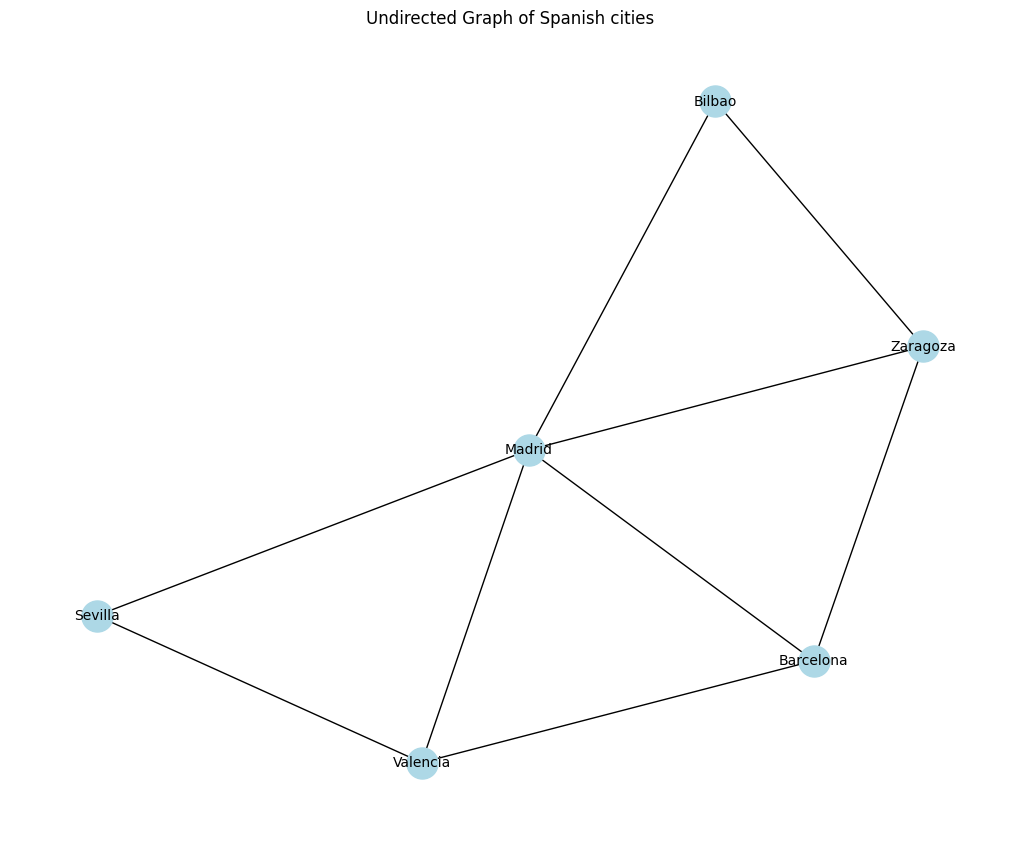

In [4]:
def create_example_graph():
    """Creates an example undirected graph for testing"""
    G = nx.Graph()
    
    # Add nodes (cities)
    cities = ['Madrid', 'Barcelona', 'Valencia', 'Sevilla', 'Bilbao', 'Zaragoza']
    G.add_nodes_from(cities)
    
    # Add edges (no weights)
    edges = [
        ('Madrid', 'Barcelona'),
        ('Madrid', 'Valencia'),
        ('Madrid', 'Sevilla'),
        ('Madrid', 'Bilbao'),
        ('Madrid', 'Zaragoza'),
        ('Barcelona', 'Valencia'),
        ('Barcelona', 'Zaragoza'),
        ('Valencia', 'Sevilla'),
        ('Zaragoza', 'Bilbao')
    ]
    
    # Add the edges
    G.add_edges_from(edges)
    
    return G

# Create and visualize the graph
G = create_example_graph()

# Visualize the graph
pos = nx.spring_layout(G, seed=42)  # Node positioning
plt.figure(figsize=(10, 8))
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500, font_size=10)
plt.title("Undirected Graph of Spanish cities")
plt.show()

In [5]:
# Define source and target nodes
source = 'Bilbao'
target = 'Sevilla'

# Run Random Walk
rw_steps, rw_path, success = random_walk_numpy(G, source, target, max_steps=100, seed=42)

if success:
    print(f"Random Walk from {source} to {target}:")
    print(f"Number of steps: {rw_steps}")
    print(f"Path found: {rw_path}")
    print(f"Path length: {len(rw_path) - 1} edges")
else:
    print(f"Random Walk failed to find {target} from {source} within {rw_steps} steps.")
    print(f"Partial path: {rw_path}")

# Compare with NetworkX (shortest path)
shortest_path = nx.shortest_path(G, source, target)
print(f"\nNetworkX result (shortest path):")
print(f"Shortest path: {shortest_path}")
print(f"Path length: {len(shortest_path) - 1} edges")

# Check if Random Walk found the shortest path (unlikely)
if success and len(rw_path) == len(shortest_path):
    print("\nRandom Walk found the shortest path by chance!")
elif success:
    print(f"\nRandom Walk found a valid path, but not the shortest one. Difference: {len(rw_path) - len(shortest_path)} edges")

Random Walk from Bilbao to Sevilla:
Number of steps: 5
Path found: ['Bilbao', 'Madrid', 'Bilbao', 'Madrid', 'Sevilla']
Path length: 4 edges

NetworkX result (shortest path):
Shortest path: ['Bilbao', 'Madrid', 'Sevilla']
Path length: 2 edges

Random Walk found a valid path, but not the shortest one. Difference: 2 edges
